# Carrión por síntomas — Red Neuronal vs. Árbol de Decisión

Clasificación de la **fase** de la enfermedad de Carrión a partir de **síntomas**:
`AGUDA` (Fiebre de la Oroya) vs `ERUPTIVA` (Verruga Peruana).

> ⚠️ **Dataset SIMULADO con fines educativos.** No proviene del MINSA ni de
> ninguna fuente real: los datos abiertos peruanos de vigilancia no publican
> síntomas por paciente. Aquí se generan sintéticamente muestreando cada síntoma
> con probabilidades condicionadas a la fase, según los criterios clínicos de la
> literatura médica. El objetivo es comparar ambos modelos sobre datos donde las
> variables (síntomas) sí son clínicamente informativas.

## 1. Generación del dataset sintético

Para cada caso se sortea la fase y luego cada síntoma con `P(síntoma | fase)`
basada en la clínica:
- **AGUDA**: fiebre alta, anemia/palidez, fatiga, cefalea, ictericia, hepato/esplenomegalia.
- **ERUPTIVA**: verrugas/nódulos rojizos en la piel que pueden sangrar.

In [1]:
import numpy as np, pandas as pd
rng = np.random.RandomState(42)
N = 6000
SINTOMAS = ["fiebre_alta","palidez_anemia","fatiga_debilidad","dolor_cabeza_cuerpo",
            "ictericia","ganglios_hinchazon","verrugas_piel","sangrado_lesiones"]
P_AGUDA = {"fiebre_alta":.92,"palidez_anemia":.90,"fatiga_debilidad":.88,"dolor_cabeza_cuerpo":.80,
           "ictericia":.55,"ganglios_hinchazon":.50,"verrugas_piel":.05,"sangrado_lesiones":.03}
P_ERUPTIVA = {"fiebre_alta":.12,"palidez_anemia":.16,"fatiga_debilidad":.35,"dolor_cabeza_cuerpo":.30,
              "ictericia":.03,"ganglios_hinchazon":.08,"verrugas_piel":.90,"sangrado_lesiones":.62}
fases = rng.choice(["AGUDA","ERUPTIVA"], size=N, p=[.5,.5])
filas = []
for fase in fases:
    P = P_AGUDA if fase=="AGUDA" else P_ERUPTIVA
    fila = {s: int(rng.rand() < P[s]) for s in SINTOMAS}
    fila["fase"] = fase
    filas.append(fila)
df = pd.DataFrame(filas, columns=SINTOMAS+["fase"])
# ruido: voltea un sintoma al azar en ~8% de los casos (presentaciones atipicas)
for i in rng.choice(N, int(.08*N), replace=False):
    s = rng.choice(SINTOMAS); df.at[i,s] = 1 - df.at[i,s]
print(df["fase"].value_counts())
df.head()

fase
AGUDA       3007
ERUPTIVA    2993
Name: count, dtype: int64


,fiebre_alta,palidez_anemia,fatiga_debilidad,dolor_cabeza_cuerpo,ictericia,ganglios_hinchazon,verrugas_piel,sangrado_lesiones,fase
0,1,1,1,1,1,0,0,0,AGUDA
1,0,0,0,0,0,0,1,0,ERUPTIVA
2,0,0,0,1,0,0,1,1,ERUPTIVA
3,1,0,0,1,0,0,1,1,ERUPTIVA
4,1,1,1,1,1,0,0,0,AGUDA


In [2]:
from sklearn.model_selection import train_test_split
X = df[SINTOMAS].values.astype(float)
Y = (df["fase"]=="ERUPTIVA").astype(int).values   # AGUDA=0, ERUPTIVA=1
Xtr,Xte,ytr,yte = train_test_split(X,Y,test_size=.2,random_state=42,stratify=Y)
print("train:", Xtr.shape, " test:", Xte.shape)

train: (4800, 8)  test: (1200, 8)


## 2. Árbol de Decisión

No requiere normalización (los síntomas ya son 0/1).

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
arbol = DecisionTreeClassifier(criterion="entropy", random_state=42).fit(Xtr,ytr)
print("Arbol  train: %.2f%%  test: %.2f%%" % (arbol.score(Xtr,ytr)*100, arbol.score(Xte,yte)*100))
print(confusion_matrix(yte, arbol.predict(Xte)))
print(classification_report(yte, arbol.predict(Xte), target_names=["AGUDA","ERUPTIVA"]))

Arbol  train: 99.00%  test: 98.33%
[[591  10]
 [ 10 589]]
              precision    recall  f1-score   support

       AGUDA       0.98      0.98      0.98       601
    ERUPTIVA       0.98      0.98      0.98       599

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



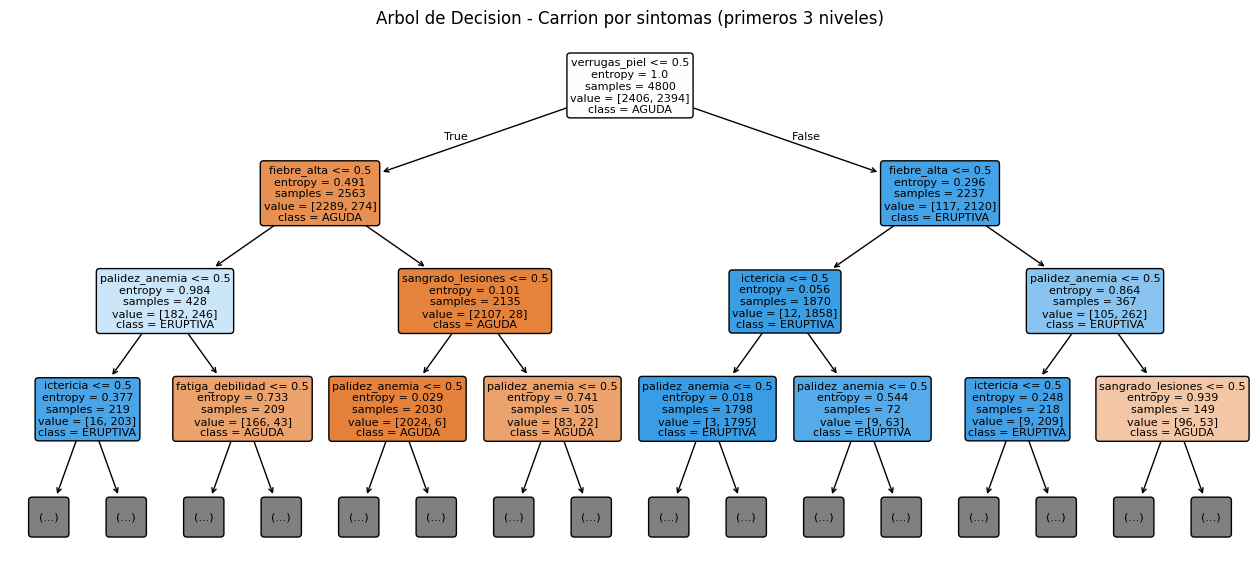

In [4]:
plt.figure(figsize=(16,7))
plot_tree(arbol, max_depth=3, feature_names=SINTOMAS,
          class_names=["AGUDA","ERUPTIVA"], filled=True, fontsize=8, rounded=True)
plt.title("Arbol de Decision - Carrion por sintomas (primeros 3 niveles)")
plt.show()

## 3. Red Neuronal (8 → 32 → 32 → 1)

In [5]:
import keras
from keras import layers
red = keras.Sequential()
red.add(layers.Dense(32, input_dim=len(SINTOMAS), activation='relu'))
red.add(layers.Dense(32, activation='relu', name='layer1'))
red.add(layers.Dense(1, activation='sigmoid', name='layer2'))
red.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
red.fit(Xtr, ytr, epochs=200, batch_size=64, verbose=0)
print("RN  train: %.2f%%  test: %.2f%%" % (red.evaluate(Xtr,ytr,verbose=0)[1]*100,
                                            red.evaluate(Xte,yte,verbose=0)[1]*100))
yp = (red.predict(Xte,verbose=0).ravel()>=0.5).astype(int)
print(confusion_matrix(yte, yp))
print(classification_report(yte, yp, target_names=["AGUDA","ERUPTIVA"]))

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RN  train: 98.92%  test: 98.67%


[[593   8]
 [  8 591]]
              precision    recall  f1-score   support

       AGUDA       0.99      0.99      0.99       601
    ERUPTIVA       0.99      0.99      0.99       599

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200



## 4. Predicción de un caso por síntomas

In [6]:
# orden: fiebre, palidez, fatiga, dolor_cabeza, ictericia, ganglios, verrugas, sangrado
caso_aguda    = np.array([[1,1,1,1,0,0,0,0]])   # sintomas sistemicos -> AGUDA
caso_eruptiva = np.array([[0,0,0,0,0,0,1,1]])   # verrugas + sangrado -> ERUPTIVA
for nombre, caso in [("sistemico", caso_aguda), ("cutaneo", caso_eruptiva)]:
    a = arbol.predict(caso)[0]
    r = int(red.predict(caso, verbose=0)[0][0] >= 0.5)
    et = lambda v: "ERUPTIVA" if v==1 else "AGUDA"
    print(f"caso {nombre:9s} -> Arbol: {et(a):8s} | RN: {et(r)}")

caso sistemico -> Arbol: AGUDA    | RN: AGUDA
caso cutaneo   -> Arbol: ERUPTIVA | RN: ERUPTIVA


## 5. Interpretación

Cuando las variables de entrada son **clínicamente informativas** (síntomas que
distinguen bien cada fase), **ambos modelos alcanzan una exactitud muy alta**
(~98%) y coinciden en casi todos los casos. Esto contrasta con el modelo basado
en datos de vigilancia del MINSA (edad, sexo, zona, fecha), donde el árbol
sobreajustaba y la red generalizaba mejor.

**Conclusión:** la *calidad de las variables* influye tanto o más que la
elección del modelo. Con buenos predictores, RN y Árbol rinden parecido; la
diferencia entre modelos se nota sobre todo cuando los datos son débiles o
ruidosos.

*(Recordatorio: este dataset es simulado; sirve para ilustrar la comparación,
no para diagnóstico real.)*